# 02. Entendimiento de los datos

En este notebook comienzo a trabajar con la base real. Primero leo únicamente
las variables necesarias para el análisis, de forma que el proceso sea más
claro y eficiente, aunque también verifico cuántas columnas contiene la fuente.

## Objetivos de esta etapa

- Confirmar dimensiones y variable objetivo.
- Calcular la tasa general de dificultad de pago.
- Revisar valores faltantes en las variables seleccionadas.
- Identificar reglas de limpieza antes de crear indicadores.

## Preparación del entorno y carga

| Función o instrucción | Qué hace | Por qué es necesaria |
|---|---|---|
| `Path.cwd()` | Obtiene la carpeta actual | Permite ejecutar desde la raíz o desde `notebooks/` |
| `pd.read_csv(..., nrows=0)` | Lee solamente los nombres de columnas | Cuenta variables originales sin cargar todo dos veces |
| `pd.read_csv(..., usecols=...)` | Carga únicamente columnas escogidas | Mantener visible qué variables analizaré |
| `assert` | Verifica que las columnas existan | Detenerme si el archivo no tiene la estructura esperada |

### Lectura línea por línea del código

| Línea o instrucción | Qué estoy haciendo |
|---|---|
| `from pathlib import Path` | Importo el manejo de rutas del proyecto. |
| `import matplotlib.pyplot as plt` | Importo herramientas para construir y guardar gráficos. |
| `import pandas as pd` | Importo Pandas para leer y analizar tablas. |
| `import seaborn as sns` | Importo Seaborn para crear visualizaciones estadísticas. |
| `PROJECT_ROOT = ...` | Detecto si ejecuto desde la raíz o desde la carpeta de notebooks. |
| `DATA_PATH = ...` | Defino la ubicación del archivo fuente. |
| `IMAGES_PATH = ...` | Defino dónde guardaré las imágenes del análisis. |
| `IMAGES_PATH.mkdir(...)` | Creo la carpeta de imágenes si todavía no existe. |
| `selected_columns = [...]` | Declaro, de forma visible, las variables que sí utilizaré en el proyecto. |
| `original_columns = pd.read_csv(..., nrows=0).columns` | Leo solamente los encabezados para conocer la estructura original sin cargar los datos completos. |
| `missing_columns = ...` | Comparo mis variables elegidas con las columnas reales para encontrar faltantes. |
| `assert not missing_columns, ...` | Evito continuar si el archivo no incluye alguna variable necesaria. |
| `raw_data = pd.read_csv(..., usecols=selected_columns)` | Cargo las solicitudes usando únicamente las columnas del análisis. |
| `print(...)` finales | Muestro el tamaño de la base y cuántas variables conservaré. |

In [1]:
# Importo Path para manejar rutas del proyecto de manera portable.
from pathlib import Path

# Importo las librerías necesarias para tablas y visualizaciones.
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Localizo la raíz del proyecto aunque ejecute este notebook desde notebooks/.
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
# Defino la ruta de lectura del dataset original.
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "application_train.csv"
# Defino y creo la carpeta donde guardaré las gráficas publicables.
IMAGES_PATH = PROJECT_ROOT / "images"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

# Selecciono solo variables útiles para responder las preguntas de riesgo crediticio.
selected_columns = [
    "TARGET", "NAME_CONTRACT_TYPE", "CODE_GENDER", "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY", "CNT_CHILDREN", "AMT_INCOME_TOTAL", "AMT_CREDIT",
    "AMT_ANNUITY", "AMT_GOODS_PRICE", "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE",
    "DAYS_BIRTH", "DAYS_EMPLOYED", "OCCUPATION_TYPE", "CNT_FAM_MEMBERS",
    "REGION_RATING_CLIENT", "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
]
# Leo únicamente los encabezados para validar la estructura sin cargar todavía toda la tabla.
original_columns = pd.read_csv(DATA_PATH, nrows=0).columns
# Comparo las columnas requeridas contra las realmente disponibles.
missing_columns = sorted(set(selected_columns) - set(original_columns))
# Interrumpo el análisis si falta una variable necesaria.
assert not missing_columns, f"Faltan columnas necesarias: {missing_columns}"

# Cargo las filas utilizando exclusivamente las columnas seleccionadas.
raw_data = pd.read_csv(DATA_PATH, usecols=selected_columns)

# Muestro dimensiones iniciales para documentar el insumo del análisis.
print(f"Solicitudes: {len(raw_data):,}")
print(f"Variables en la fuente original: {len(original_columns)}")
print(f"Variables seleccionadas para el análisis: {raw_data.shape[1]}")

Solicitudes: 307,511
Variables en la fuente original: 122
Variables seleccionadas para el análisis: 22


## Distribución de `TARGET`

Aquí calculo el indicador central del proyecto: la proporción de solicitudes
que históricamente presentaron dificultad de pago.

| Función | Qué hace | Resultado esperado |
|---|---|---|
| `.value_counts()` | Cuenta solicitudes de cada resultado | Cantidad con y sin dificultad |
| `.mean()` sobre `TARGET` | Promedia ceros y unos | Tasa de dificultad de pago |
| `sns.barplot()` | Dibuja una comparación de categorías | Visual para README y dashboard |
| `plt.savefig()` | Guarda la imagen | Artefacto publicable sin exponer filas |

### Lectura línea por línea del código

| Línea o instrucción | Qué estoy haciendo |
|---|---|
| `target_summary = (...)` | Inicio una tabla resumen de la variable objetivo `TARGET`. |
| `raw_data["TARGET"].value_counts()` | Cuento cuántas solicitudes tienen valor `0` y cuántas tienen valor `1`. |
| `.rename_axis("TARGET")` | Le doy nombre al índice que contiene esos valores. |
| `.reset_index(name="total_solicitudes")` | Convierto el resultado en tabla y nombro la columna de conteo. |
| `target_summary["resultado"] = ...map(...)` | Cambio `0` y `1` por etiquetas comprensibles para presentar el resultado. |
| `target_summary["porcentaje"] = (...)` | Divido cada conteo entre el total y lo multiplico por 100. |
| `.round(2)` | Redondeo el porcentaje a dos decimales. |
| `display(...)` | Presento la tabla con etiqueta, cantidad y porcentaje. |
| `default_rate = ...mean() * 100` | Calculo la tasa general: al promediar una variable 0/1 obtengo la proporción de casos con dificultad. |
| `print(...)` | Comunico la tasa general en texto. |
| `sns.set_theme(...)` | Aplico un estilo visual uniforme a la gráfica. |
| `plt.figure(...)` | Creo el lienzo y defino su tamaño. |
| `ax = sns.barplot(...)` | Dibujo las barras con los porcentajes de ambos resultados. |
| `ax.set(...)` | Escribo título y nombres de los ejes. |
| `for container ... ax.bar_label(...)` | Coloco el porcentaje encima de cada barra. |
| `plt.tight_layout()` | Ajusto espacios para evitar textos recortados. |
| `plt.savefig(...)` | Guardo la visualización para el repositorio. |
| `plt.show()` | Muestro la gráfica dentro del notebook. |

,resultado,total_solicitudes,porcentaje
0,Sin dificultad,282686,91.93
1,Con dificultad,24825,8.07


Tasa general de dificultad de pago: 8.07%


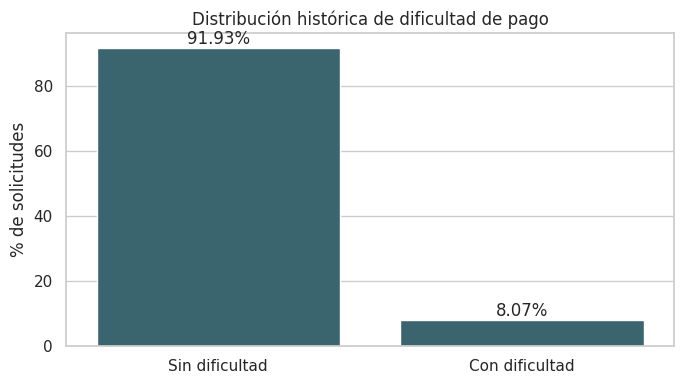

In [2]:
# Construyo una tabla que cuente cuántas solicitudes hay por resultado de pago.
target_summary = (
    raw_data["TARGET"]
    # Cuento valores 0 y 1 de la variable objetivo.
    .value_counts()
    # Nombraré el valor agrupador como TARGET al volverlo columna.
    .rename_axis("TARGET")
    # Convierto el conteo en DataFrame y nombro la cantidad calculada.
    .reset_index(name="total_solicitudes")
)
# Traduco los valores numéricos de TARGET a etiquetas comprensibles.
target_summary["resultado"] = target_summary["TARGET"].map(
    {0: "Sin dificultad", 1: "Con dificultad"}
)
# Calculo el peso porcentual de cada resultado sobre todas las solicitudes.
target_summary["porcentaje"] = (
    target_summary["total_solicitudes"] / len(raw_data) * 100
).round(2)
# Presento la tabla resumen que servirá como primer KPI del proyecto.
display(target_summary[["resultado", "total_solicitudes", "porcentaje"]])

# Como TARGET es 0/1, su promedio equivale a la tasa con dificultad de pago.
default_rate = raw_data["TARGET"].mean() * 100
# Muestro la tasa calculada en formato porcentual.
print(f"Tasa general de dificultad de pago: {default_rate:.2f}%")

# Configuro un estilo visual limpio para la gráfica.
sns.set_theme(style="whitegrid")
# Creo el lienzo donde dibujaré la distribución de TARGET.
plt.figure(figsize=(7, 4))
# Grafico el porcentaje de solicitudes con y sin dificultad de pago.
ax = sns.barplot(data=target_summary, x="resultado", y="porcentaje", color="#326B77")
# Agrego título y etiquetas para que la imagen sea interpretable por sí sola.
ax.set(title="Distribución histórica de dificultad de pago", xlabel="", ylabel="% de solicitudes")
# Recorro las barras para escribir su porcentaje encima de cada una.
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")
# Ajusto márgenes, exporto la imagen y la muestro en el notebook.
plt.tight_layout()
plt.savefig(IMAGES_PATH / "target_distribution.png", dpi=160)
plt.show()

### Conclusión parcial

La base contiene **307.511 solicitudes** y **24.825** presentan dificultad de
pago, equivalentes al **8,07%**. El grupo relevante es minoritario, pero no voy
a tratarlo como un problema de predicción: mi foco es describir dónde aparecen
diferencias útiles para seguimiento y visualización.

## Valores faltantes y anomalías que debo tratar

| Función | Qué hace | Para qué me sirve |
|---|---|---|
| `.isna().mean()` | Calcula proporción de nulos por variable | Priorizar tratamiento y documentar limitaciones |
| `.sort_values()` | Ordena de mayor a menor | Mostrar primero los campos más incompletos |
| Comparación `== 365243` | Detecta centinela de empleo | Evitar convertirlo en cientos de años laborales |

### Lectura línea por línea del código

| Línea o instrucción | Qué estoy haciendo |
|---|---|
| `missing_summary = (...)` | Construyo una tabla para diagnosticar datos faltantes. |
| `raw_data.isna().mean().mul(100).round(2)` | Detecto nulos, calculo su porcentaje por columna y redondeo el resultado. |
| `.sort_values(ascending=False)` | Ordeno de mayor a menor porcentaje de faltantes. |
| `.rename("faltantes_pct")` | Asigno un nombre claro al porcentaje calculado. |
| `.reset_index().rename(...)` | Convierto las variables en una columna llamada `variable`. |
| `display(missing_summary.head(10))` | Muestro las diez variables seleccionadas con más nulos. |
| `sentinel_count = int((...).sum())` | Cuento las filas donde empleo usa el valor especial `365243`. |
| `print(...)` | Explico cuántos valores centinela trataré como información no disponible. |

In [3]:
# Creo un resumen del porcentaje de datos faltantes por variable elegida.
missing_summary = (
    # Identifico nulos, calculo la proporción y la convierto a porcentaje.
    raw_data.isna().mean().mul(100).round(2)
    # Ordeno primero las variables con mayor ausencia de información.
    .sort_values(ascending=False)
    # Doy un nombre explícito al valor calculado.
    .rename("faltantes_pct")
    # Convierto el índice de variables en una columna normal.
    .reset_index()
    .rename(columns={"index": "variable"})
)
# Muestro las diez variables seleccionadas con más faltantes.
display(missing_summary.head(10))

# Cuento el valor centinela que Home Credit usa para empleo no informado.
sentinel_count = int((raw_data["DAYS_EMPLOYED"] == 365243).sum())
# Comunico la regla de limpieza que aplicaré en el siguiente notebook.
print(
    f"Registros con DAYS_EMPLOYED=365243: {sentinel_count:,}. "
    "En la limpieza los interpretaré como dato no informado."
)

,variable,faltantes_pct
0,EXT_SOURCE_1,56.38
1,OCCUPATION_TYPE,31.35
2,EXT_SOURCE_3,19.83
3,EXT_SOURCE_2,0.21
4,AMT_GOODS_PRICE,0.09
5,TARGET,0.00
6,CNT_CHILDREN,0.00
7,FLAG_OWN_REALTY,0.00
8,FLAG_OWN_CAR,0.00
9,CODE_GENDER,0.00


Registros con DAYS_EMPLOYED=365243: 55,374. En la limpieza los interpretaré como dato no informado.


### Decisión para la siguiente etapa

Conservaré variables de ingreso, crédito, cuota, edad, empleo, ocupación,
educación y vivienda porque responden preguntas de negocio. Convertiré días a
años y crearé ratios financieros interpretables. Los puntajes `EXT_SOURCE_*`
se preservan para documentar su disponibilidad, pero no construiré un score ni
un modelo con ellos.

Continúo en `03_data_cleaning_feature_engineering.ipynb`.